# Miner revenue is running hot. Is that when you sell? ⛏️
### The Puell Multiple — a famous on-chain "top/bottom" gauge you can rebuild *exactly* from price alone

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Times_tops_%26_bottoms%3F: Busted](https://img.shields.io/badge/Times_tops_%26_bottoms%3F-Busted-8b949e?style=flat-square)

Every day, the Bitcoin network mints new coins and hands them to miners, who mostly sell them to pay for electricity and machines. The **Puell Multiple** asks a simple question: is that daily flow of new-coin revenue running **hot or cold** versus its own past year?

The folklore: when miner revenue is way above its yearly average (Puell **> 4**), everyone's euphoric and it's a **top — sell**. When it's way below (Puell **< 0.5**), miners are getting crushed and capitulating — a **bottom — buy**. It *sounds* deep because it's "on-chain," not just price.

> 📓 **Plain-language layer.** Want the HAC *t*-stats, the placebo and the horse race? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> 🔬 **The twist we'll keep coming back to.** The Puell Multiple's only non-price ingredient — how many coins are minted each day — is a *fixed, known* schedule (it halves every four years). So we can rebuild the whole thing from BTC's price and a hardcoded halving table, no mystery data feed required. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from puell_multiple import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    BTC = data.load_btc()
    PM = data.puell_multiple(BTC).dropna()
else:
    BTC = PM = None
print("real cache present:", HAVE_REAL,
      "| Puell points:", (0 if PM is None else len(PM)))

# frozen headline numbers (mirror of docs/results.md)
R = {'btc_lo': '2014-09-17', 'btc_hi': '2026-06-30', 'btc_n': 4305, 'fp_btc': '9529d5277775', 'puell_lo': '2015-09-16', 'puell_hi': '2026-06-30', 'puell_n': 3941, 'puell_min': 0.4, 'puell_med': 1.12, 'puell_max': 5.95, 'high': 4.0, 'low': 0.5, 'reg': {30: (0.0284, 0.67, 0.0037, 3911), 90: (0.0027, 0.02, 0.0, 3851), 180: (-0.1616, -0.74, 0.0155, 3761)}, 'horse_puell_t': -1.76, 'horse_mom_t': 1.7, 'band': {30: {'bottom': (6.79, 6.54, 0.75, 0.08, 0.479, 75), 'neutral': (6.84, 3.03, 0.57, 0.25, None, 3814), 'top': (-17.13, -20.3, 0.14, -4.6, 0.0, 22)}, 90: {'bottom': (2.01, -1.81, 0.44, -11.1, 1.0, 75), 'neutral': (24.03, 11.17, 0.61, 0.65, None, 3754), 'top': (-44.18, -46.76, 0.0, -19.14, 0.0, 22)}, 180: {'bottom': (60.93, 49.62, 0.61, 0.67, 0.304, 75), 'neutral': (55.59, 31.69, 0.66, 0.22, None, 3664), 'top': (-56.89, -59.87, 0.0, -43.47, 0.0, 22)}}, 'top_days': 22, 'top_episode': '2017-12-04 -> 2018-01-06', 'bottom_days': 75, 'bottom_episodes': 3, 'placebo_draws': 20000, 'years': 10.79, 'n_flips': 7, 'exposure': 99.42, 'strat_total': 24841.1, 'strat_cagr': 66.8, 'strat_sharpe': 1.114, 'bh_total': 25461.4, 'bh_cagr': 67.18, 'bh_sharpe': 1.107, 'excess_cagr': -0.97, 'excess_t': -0.21, 'sweep': {3.0: (18921.1, 97.6, 1.09), 3.5: (20377.3, 98.9, 1.09), 4.0: (24841.1, 99.4, 1.11), 4.5: (22944.2, 99.6, 1.1)}, 'syn_planted_slope': -11.78, 'syn_planted_t': -26.09, 'syn_null_mean': 0.06, 'syn_null_sd': 1.22, 'syn_null_fire': 1}


real cache present: True | Puell points: 3941


## The answer first

| Question | Answer |
|---|---|
| Does a high/low Puell reading predict what BTC does next? | **No.** In a proper regression it explains ~nothing (best statistic **0.67**, far below the bar), and it isn't even reliably pointing the "contrarian" way. |
| Does "buy the bottom" (Puell < 0.5) work? | **No — it's worse than a random day.** Buying deep lows earned **+2%** over the next 90 days versus **+24%** for an ordinary day. |
| Does "sell the top" (Puell > 4) work? | **Once.** It fired on essentially a single event — the **2017 blow-off top** — and never cleanly again. One data point is a story, not a signal. |
| Could you have timed the market with it? | **No.** The buy-low/sell-high rule ends up **99% invested** and actually **loses** to just holding BTC (**+24,841%** vs **+25,461%**). |

> A metric that turns out to be *price divided by its own one-year average* can't tell you much that the price chart didn't already.

## 1 · The claim

> *"Miners are the market's constant sellers. When their daily revenue is far above its 365-day average, the market is overheated — a top. When it's far below, miners are capitulating — a bottom. Watch the Puell Multiple: sell above 4, buy below 0.5."*

It's a genuinely clever framing — it ties price to the **supply side** (issuance), which is fixed by protocol and steps down at every halving. David Puell's original charts light up the 2013 and 2017 tops and the 2015 and 2018 bottoms.

## 2 · So what?

If it worked, the Puell Multiple would be one of the cleanest cycle-timing tools in crypto — a supply-anchored "are we hot or cold" dial that beats staring at the price. It's on every on-chain dashboard and gets cited at every cycle. The stakes: if buying low-Puell and selling high-Puell genuinely beats holding, that's real, bankable timing alpha in the most liquid crypto asset. If it doesn't, it's one more chart that *looks* rigorous because it says "on-chain."

## 3 · How would we even know?

- **Rebuild it honestly.** Daily miner revenue = (coins minted that day) × price. Coins minted per day is the **known halving schedule** (50 → 25 → 12.5 → 6.25 → 3.125 BTC). Divide today's revenue by its trailing 365-day average — that's the Puell Multiple, reconstructed from price + a hardcoded table.
- **The prediction test.** Does today's Puell reading forecast BTC's return over the next 1/3/6 months?
- **The bands test.** After Puell > 4 ("top") and Puell < 0.5 ("bottom"), what did BTC *actually* do — and is that better than a random day?
- **The trade test.** If you'd sold to cash whenever Puell > 4 and held otherwise, would you have beaten simply buying and holding?

## 4 · The teardown — let's actually look

**First, here's the reconstructed Puell Multiple** with the classic sell/buy bands. Notice how rarely it actually reaches the extremes.

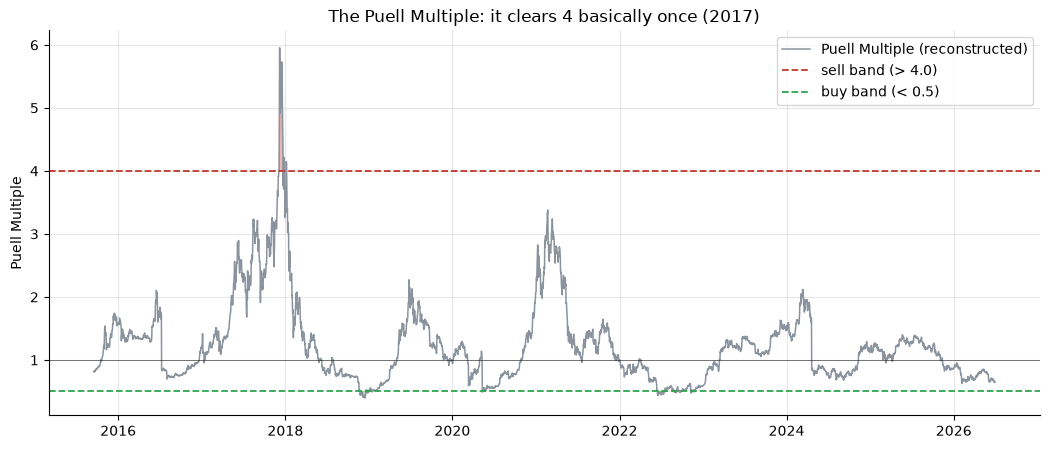

reconstructed from BTC price + halving schedule; range 0.40 .. 5.95
days in SELL band (>4): 22  (all one 2017-18 blow-off)  |  days in BUY band (<0.5): 75  (~3 episodes)


In [2]:
if HAVE_REAL:
    pm = PM
else:
    pm = None
fig, ax = plt.subplots(figsize=(10.6, 4.6))
if pm is not None:
    ax.plot(pm.index, pm.values, color=GREY, lw=1.1, label='Puell Multiple (reconstructed)')
ax.axhline(R['high'], color=RED, ls='--', lw=1.3, label=f"sell band (> {R['high']})")
ax.axhline(R['low'], color=GREEN, ls='--', lw=1.3, label=f"buy band (< {R['low']})")
ax.axhline(1.0, color='k', lw=.7, alpha=.5)
if pm is not None:
    ax.fill_between(pm.index, R['high'], pm.values, where=(pm.values >= R['high']), color=RED, alpha=.35)
    ax.fill_between(pm.index, R['low'], pm.values, where=(pm.values <= R['low']), color=GREEN, alpha=.35)
ax.set_ylabel('Puell Multiple'); ax.set_title('The Puell Multiple: it clears 4 basically once (2017)')
ax.legend(loc='upper right'); plt.tight_layout(); plt.show()
print(f"reconstructed from BTC price + halving schedule; range {R['puell_min']:.2f} .. {R['puell_max']:.2f}")
print(f"days in SELL band (>4): {R['top_days']}  (all one 2017-18 blow-off)  |  "
      f"days in BUY band (<0.5): {R['bottom_days']}  (~{R['bottom_episodes']} episodes)")

The red "sell" zone is essentially a **single spike in late 2017**. That's the first honest problem: a rule that only triggers once can't be tested like a rule that triggers often. Now — **does the reading predict what comes next?**

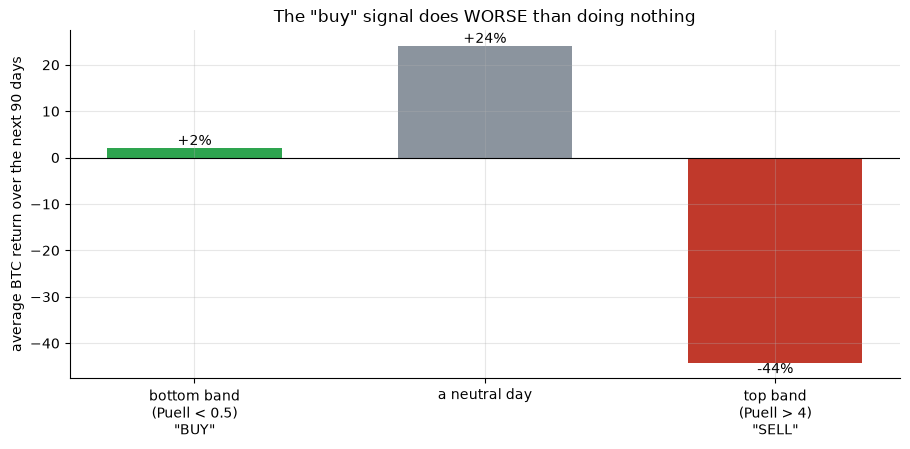

In [3]:
if HAVE_REAL:
    tab = st.state_forward_stats(PM, BTC, horizon=90, high=R['high'], low=R['low'])
    order = ['bottom (buy)', 'neutral', 'top (sell)']
    means = [tab.loc[b, 'mean_pct'] for b in order]
else:
    means = [R['band'][90]['bottom'][0], R['band'][90]['neutral'][0], R['band'][90]['top'][0]]
labels = ['bottom band\n(Puell < 0.5)\n"BUY"', 'a neutral day', 'top band\n(Puell > 4)\n"SELL"']
cols = [GREEN, GREY, RED]
fig, ax = plt.subplots(figsize=(9.2, 4.6))
ax.bar(labels, means, color=cols, width=.6)
for i, v in enumerate(means): ax.annotate(f'{v:+.0f}%', (i, v), ha='center', va='bottom' if v>=0 else 'top')
ax.axhline(0, color='k', lw=.8)
ax.set_ylabel('average BTC return over the next 90 days')
ax.set_title('The "buy" signal does WORSE than doing nothing')
plt.tight_layout(); plt.show()

Look at the green bar. After a "buy the bottom" signal, BTC returned **+2%** over 90 days — *less* than the **+24%** you'd get on an ordinary day. The capitulation-buy half of the folklore is empty. The red "sell" bar is dramatically negative — but remember, that's the one 2017 blow-off. **So would the trade have paid?**

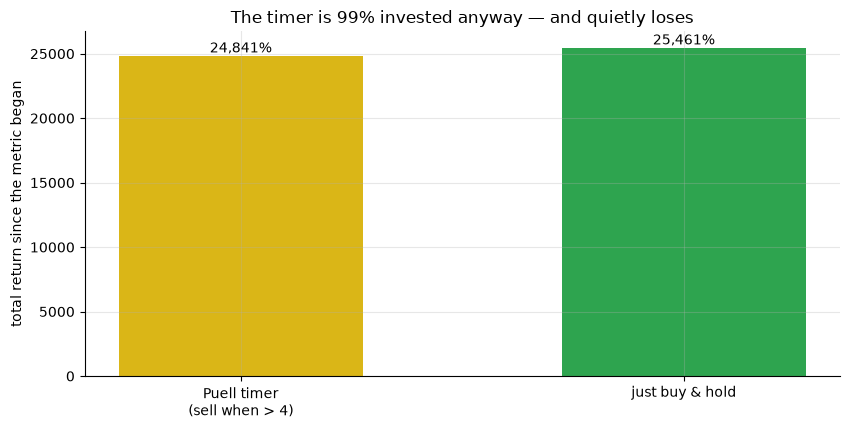

Puell timer: +24,841% (Sharpe 1.11, invested 99.4% of the time)
buy & hold : +25,461% (Sharpe 1.11, invested 100%)


In [4]:
if HAVE_REAL:
    tb = st.backtest_timing(PM, BTC, high=R['high'], cost_bps=10.0)
    st_tot, bh_tot = tb['strat_total_pct'], tb['bh_total_pct']
    st_shp, bh_shp = tb['strat_sharpe'], tb['bh_sharpe']; expo = tb['exposure_pct']
else:
    st_tot, bh_tot = R['strat_total'], R['bh_total']
    st_shp, bh_shp = R['strat_sharpe'], R['bh_sharpe']; expo = R['exposure']
fig, ax = plt.subplots(figsize=(8.6, 4.4))
bars = ax.bar(['Puell timer\n(sell when > 4)', 'just buy & hold'], [st_tot, bh_tot],
              color=[AMBER, GREEN], width=.55)
for i, v in enumerate([st_tot, bh_tot]): ax.annotate(f'{v:,.0f}%', (i, v), ha='center', va='bottom')
ax.set_ylabel('total return since the metric began')
ax.set_title(f'The timer is {expo:.0f}% invested anyway — and quietly loses')
plt.tight_layout(); plt.show()
print(f'Puell timer: +{st_tot:,.0f}% (Sharpe {st_shp:.2f}, invested {expo:.1f}% of the time)')
print(f'buy & hold : +{bh_tot:,.0f}% (Sharpe {bh_shp:.2f}, invested 100%)')

There's the whole story. Because Puell only crosses 4 at the very peak, the rule spends **99%** of its life fully invested — it's buy-and-hold wearing a costume. And in the few weeks it *does* step aside, it re-enters before the bear market is over, so it ends up with **less** money than just holding (**+24,841%** vs **+25,461%**). No timing edge — a small timing *cost*.

## 5 · The verdict

- **Signal — None.** The Puell reading doesn't forecast BTC's next move; the "buy the bottom" band does worse than a random day; the "sell the top" band is one 2017 event.
- **Tradability — Mirage.** The buy-low/sell-high rule is 99% buy-and-hold and trails it net of costs. Any big-looking return is just being long a coin that went up 100×.
- **"Times tops & bottoms?" — Busted.** One top, zero tradable bottoms.

## 6 · Going further 🚪

- **The tell is the reconstruction.** Because the coins-per-day schedule is fixed and the blocks-per-day constant cancels, *within* a four-year halving epoch the Puell Multiple is just **price ÷ its own 365-day average**. It's a dressed-up price ratio; the only extra ingredient is a mechanical ~1-year dip after each halving.
- **What would change our mind:** more genuine top signals (we effectively have one), or a fee-inclusive version that adds real information beyond price — but that version can't be rebuilt from price alone, so it can't be audited this cleanly.
- **Sibling studies:** [293-mvrv-ratio](../../293-mvrv-ratio/) (another on-chain valuation band — same None/Mirage), [221-mayer-multiple](../../221-mayer-multiple/) (price ÷ 200-day average — the Puell Multiple's close cousin), [663-hash-ribbons](../../663-hash-ribbons/) (a hashrate buy signal — Weak/Fragile).

*Think 4 and 0.5 are the wrong thresholds, or that fees would rescue it? Fork the repo, rebuild the metric, and try — the whole thing is a pure function of price and a hardcoded halving table.*